# RINEX–SP3 Merger Output Investigation

`merge_rinex_sp3()` fonksiyonunun ürettiği birleşik veri setini (Parquet/CSV) okuyup,
seçili bir uydu ve gözlem tipi için **elevation vs SNR** grafiği çiziyoruz.

Veri setindeki sütunlar:
`epoch`, `satID`, `X`, `Y`, `Z`, `elevation`, `azimuth`, `obsType`, `SNR`

Ön koşul: `main.py` veya `merge_rinex_sp3()` ile ilgili RINEX dosyası işlenmiş olmalı;
çıktı dosyası `data/processed/` altında beklenir.

Parquet okumak için sanal ortamda `pyarrow` kurulu olmalı (`pip install pyarrow` veya `pip install -r requirements.txt`).

In [5]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Proje kökünü Python yoluna ekle ki src.* import edilebilsin
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.processing.rinex_sp3_merger import (
    DEFAULT_OUTPUT_DIR,
    build_output_stem_from_rinex_path,
)

%matplotlib inline

In [6]:
# --- AYARLAR ---
RINEX_FILE = os.path.join(PROJECT_ROOT, "data", "PTLD00AUS_R_20220010000_01D_30S_MO.rnx")
TARGET_SAT = "G05"      # İncelenecek uydu (örn. G05, R10, E02, J03)
TARGET_OBS_TYPE = "S1C" # İncelenecek SNR gözlem tipi (örn. S1C, S2W, S5Q)
MIN_ELEVATION = 0.0     # Ufuk altı verileri grafikten çıkarmak için (derece)

def load_merged_dataframe(parquet_path: str, csv_path: str) -> tuple[pd.DataFrame, str]:
    """Load merged output; prefer Parquet when pyarrow is available."""
    if os.path.isfile(parquet_path):
        try:
            return pd.read_parquet(parquet_path), parquet_path
        except ImportError as exc:
            if os.path.isfile(csv_path):
                print(
                    "Uyari: pyarrow yuklu degil, CSV dosyasi kullaniliyor. "
                    "Parquet icin: pip install pyarrow"
                )
                return pd.read_csv(csv_path, parse_dates=["epoch"]), csv_path
            raise ImportError(
                "Parquet okumak icin pyarrow gerekli. Kurulum: pip install pyarrow\n"
                "Alternatif: merge_rinex_sp3(..., output_format='csv') ile CSV uretin."
            ) from exc

    if os.path.isfile(csv_path):
        return pd.read_csv(csv_path, parse_dates=["epoch"]), csv_path

    raise FileNotFoundError(
        f"Birleşik veri dosyası bulunamadi.\n"
        f"Beklenen: {parquet_path}\n"
        f"veya      {csv_path}\n"
        f"Once merge_rinex_sp3() calistirin."
    )


# RINEX dosya adından beklenen çıktı yolunu türet
output_stem = build_output_stem_from_rinex_path(RINEX_FILE)
MERGED_PARQUET = os.path.join(PROJECT_ROOT, DEFAULT_OUTPUT_DIR, f"{output_stem}.parquet")
MERGED_CSV = os.path.join(PROJECT_ROOT, DEFAULT_OUTPUT_DIR, f"{output_stem}.csv")

df, merged_path = load_merged_dataframe(MERGED_PARQUET, MERGED_CSV)

print(f"Okunan dosya           : {merged_path}")
print(f"Toplam satir sayisi    : {len(df)}")
print(f"Uydu sayisi            : {df['satID'].nunique()}")
print(f"Gozlem tipi sayisi     : {df['obsType'].nunique()}")
print(f"Epok araligi           : {df['epoch'].min()}  ->  {df['epoch'].max()}")
df.head()

Okunan dosya           : c:\vscode_workspace\PyReflection\data\processed\PTLD00AUS_2022001_30S.parquet
Toplam satir sayisi    : 422923
Uydu sayisi            : 112
Gozlem tipi sayisi     : 16
Epok araligi           : 2022-01-01 00:00:00  ->  2022-01-01 23:59:30


,epoch,constellation,satID,arcNo,arcType,obsType,wavelength,obsValue,elevation,azimuth
0,2022-01-01,C,C06,1,-1,S2I,0.192039,43.651583,6.180764,316.018570
1,2022-01-01,C,C06,1,-1,S6I,0.236332,43.151908,6.180764,316.018570
2,2022-01-01,C,C06,1,-1,S7I,0.248349,35.075187,6.180764,316.018570
3,2022-01-01,C,C07,1,1,S2I,0.192039,194.984460,57.829448,232.452614
4,2022-01-01,C,C07,1,1,S6I,0.236332,204.173794,57.829448,232.452614


In [7]:
# Seçili uydu ve gözlem tipini filtrele
target_sat = TARGET_SAT.strip().upper()
target_obs_type = TARGET_OBS_TYPE.strip().upper()

sat_df = df[df["satID"].str.upper() == target_sat].copy()
if sat_df.empty:
    available = sorted(df["satID"].unique().tolist())
    raise ValueError(f"'{target_sat}' icin veri bulunamadi. Mevcut satID'ler: {available}")

available_obs_types = sorted(sat_df["obsType"].str.upper().unique().tolist())
plot_df = sat_df[sat_df["obsType"].str.upper() == target_obs_type].copy()
plot_df = plot_df[plot_df["elevation"] > MIN_ELEVATION].sort_values("elevation")

print(f"{target_sat} icin toplam satir              : {len(sat_df)}")
print(f"{target_sat} icin mevcut obsType'lar        : {available_obs_types}")
print(f"{target_sat} / {target_obs_type} icin satir : {len(plot_df)}")

if plot_df.empty:
    raise ValueError(
        f"'{target_sat}' / '{target_obs_type}' icin elevation > {MIN_ELEVATION} veri yok."
    )

print(f"Elevation araligi (derece) : {plot_df['elevation'].min():.2f}  ->  {plot_df['elevation'].max():.2f}")
print(f"SNR araligi (dB)           : {plot_df['obsValue'].min():.1f}  ->  {plot_df['obsValue'].max():.1f}")
plot_df.head()

G05 icin toplam satir              : 3346
G05 icin mevcut obsType'lar        : ['S1C', 'S2W', 'S2X']
G05 / S1C icin satir : 1128
Elevation araligi (derece) : 0.01  ->  54.61
SNR araligi (dB)           : 21.9  ->  298.5


,epoch,constellation,satID,arcNo,arcType,obsType,wavelength,obsValue,elevation,azimuth
81818,2022-01-01 04:27:30,G,G05,2,-1,S1C,0.190294,30.199517,0.011146,131.355689
81669,2022-01-01 04:27:00,G,G05,2,-1,S1C,0.190294,30.199517,0.187223,131.425096
81518,2022-01-01 04:26:30,G,G05,2,-1,S1C,0.190294,43.651583,0.363507,131.493983
81220,2022-01-01 04:25:30,G,G05,2,-1,S1C,0.190294,25.118864,0.716697,131.630187
81071,2022-01-01 04:25:00,G,G05,2,-1,S1C,0.190294,59.566214,0.893602,131.697500


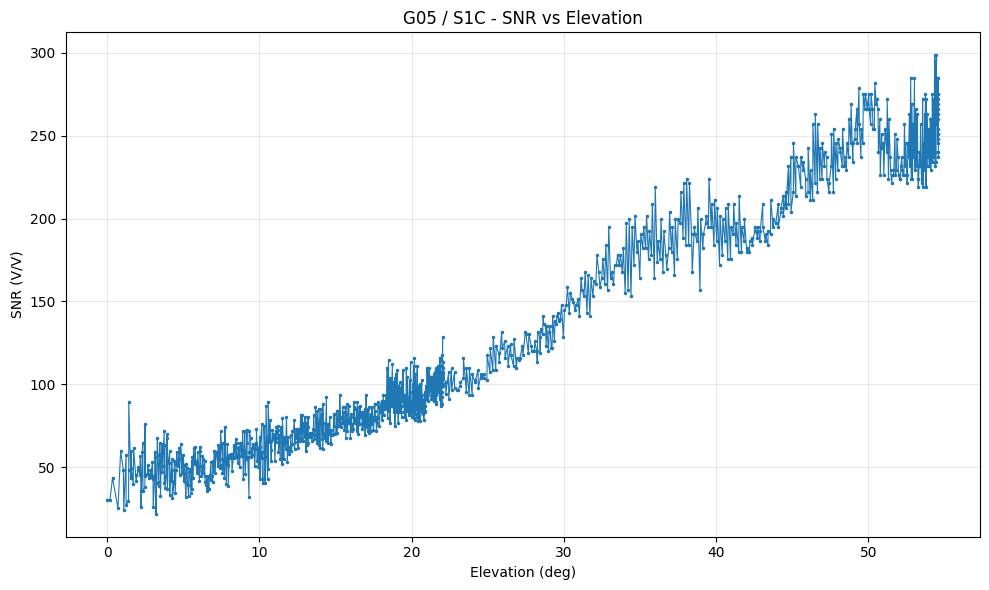

In [9]:
# --- Elevation vs SNR ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    plot_df["elevation"],
    plot_df["obsValue"],
    marker=".",
    linestyle="-",
    markersize=3,
    linewidth=0.8,
)

ax.set_title(f"{target_sat} / {target_obs_type} - SNR vs Elevation")
ax.set_xlabel("Elevation (deg)")
ax.set_ylabel("SNR (V/V)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()